<a href="https://colab.research.google.com/github/sireeshas2/data-science-final-year-project/blob/main/EData_Analysiz_model_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os, time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, accuracy_score, average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


**Reading Dataset File**

In [ ]:
file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'  # Path to the uploaded dataset
df_telco = pd.read_csv(file_path)

**Printing first Few rows**

In [ ]:
print("Dataset Head:")
df_telco.head()

Dataset Head:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Printing Shape of the Dataset**

In [ ]:
print("Dataset Shape:")
df_telco.shape

Dataset Shape:


(7043, 21)

**Printing Dataset details**

In [ ]:
print("Basic Info:")
df_telco.info()

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nul

**Descriptive statistics for numerical columns**

In [ ]:
print("\nSummary Statistics:")
df_telco.describe()


Summary Statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Checking for Missing values in Dataset**

In [ ]:
print("\nMissing Values per Column:")
missing_values = df_telco.isnull().sum()  # Count missing values in each column
print(missing_values)


Missing Values per Column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## **Distribution of Numerical Features in dataset**

<Figure size 500x500 with 0 Axes>

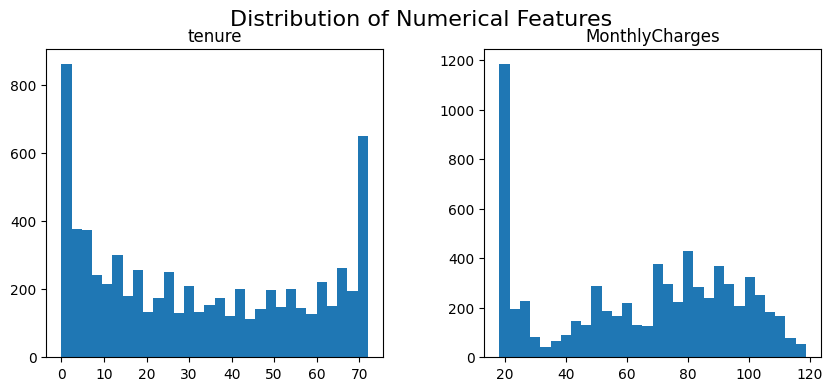

In [ ]:
numerical_features = df_telco.select_dtypes(include=['float64', 'int64']).columns

# Remove 'SeniorCitizen' from the list
numerical_features = numerical_features.drop('SeniorCitizen', errors='ignore')

plt.figure(figsize=(5, 5))
df_telco[numerical_features].hist(bins=30, figsize=(10, 4), grid=False)
plt.suptitle('Distribution of Numerical Features (excluding SeniorCitizen)', fontsize=16)
plt.show()

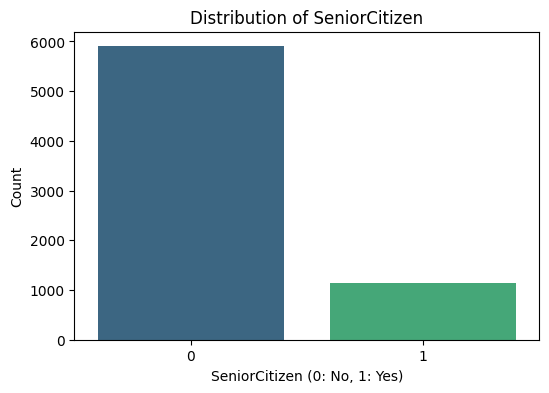

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='SeniorCitizen', data=df_telco, palette='viridis', hue='SeniorCitizen', legend=False)
plt.title('Distribution of SeniorCitizen')
plt.xlabel('SeniorCitizen (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()


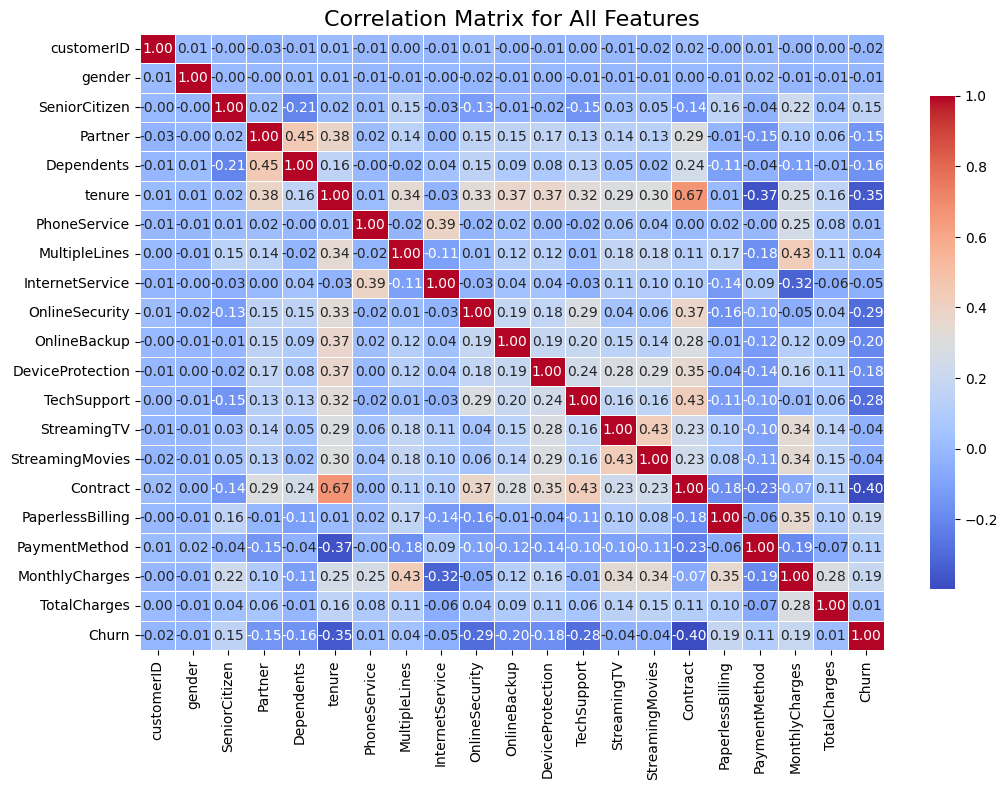

In [ ]:
# Label Encoding for Categorical Columns
label_encoder = LabelEncoder()
categorical_features = df_telco.select_dtypes(include=['object']).columns

for feature in categorical_features:
    df_telco[feature] = label_encoder.fit_transform(df_telco[feature])

#Calculate Correlation Matrix for All Features
corr_matrix = df_telco.corr()

# Plot the Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix for All Features', fontsize=16)
plt.show()

## **Class Distributtion**

/tmp/ipython-input-3497161055.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_telco, palette='plasma')


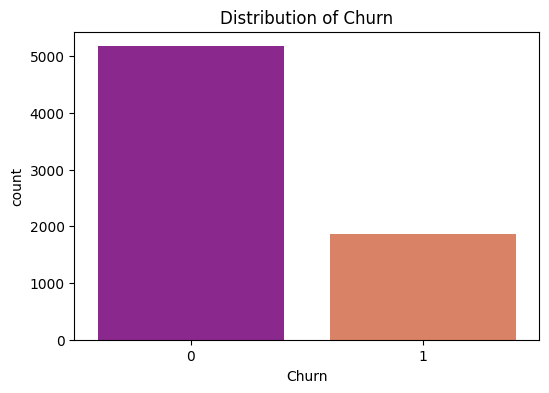

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_telco, palette='plasma')
plt.title('Distribution of Churn')
plt.show()

## **Chrun Distributtion by Class**

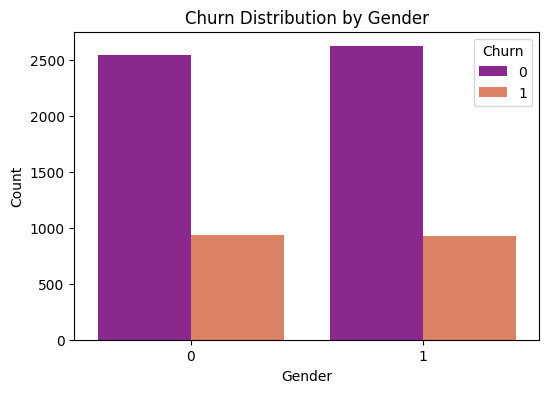

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', hue='Churn', data=df_telco, palette='plasma')
plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [ ]:
print("Counts for Churn column:")
print(df_telco['Churn'].value_counts())

print("\nCounts for Churn by Gender:")
print(df_telco.groupby('gender')['Churn'].value_counts())

Counts for Churn column:
Churn
0    5174
1    1869
Name: count, dtype: int64

Counts for Churn by Gender:
gender  Churn
0       0        2549
        1         939
1       0        2625
        1         930
Name: count, dtype: int64


# **Preparing Data for training**

In [ ]:
# %% 1) Prepare features/target from your existing df_telco (already label-encoded)
df_telco_work = df_telco.copy()

# Drop obvious IDs if present
for col in ["customerID", "CustomerID", "id", "ID"]:
    if col in df_telco_work.columns:
        df_telco_work = df_telco_work.drop(columns=[col])

# Ensure target exists and is binary numeric (0/1)
TARGET = "Churn"
assert TARGET in df_telco_work.columns, f"Target column '{TARGET}' not found."

if df_telco_work[TARGET].dtype == "O":
    df_telco_work[TARGET] = df_telco_work[TARGET].map({"No":0,"Yes":1,"0":0,"1":1})

df_telco_work = df_telco_work.dropna(subset=[TARGET])
df_telco_work[TARGET] = pd.to_numeric(df_telco_work[TARGET], errors="coerce").fillna(0).astype(int)

X_full = df_telco_work.drop(columns=[TARGET]).apply(pd.to_numeric, errors="coerce").fillna(0)
y_full = df_telco_work[TARGET].astype(int)

print("Overall class distribution:\n", y_full.value_counts().rename({0:"No Churn",1:"Churn"}))


Overall class distribution:
 Churn
No Churn    5174
Churn       1869
Name: count, dtype: int64


# **Splitting Dataset for Training and Testing**

In [ ]:
# %% 2) Robust stratified split (ensures both classes appear in train and test)
from sklearn.utils import check_random_state
import math

def safe_stratified_split(X, y, test_size=0.2, random_state=42, max_tries=50):
    y = y.astype(int)
    counts = y.value_counts()
    if counts.nunique() == 1:
        raise ValueError(f"Target has a single class ({counts.index[0]}). Add samples of the other class.")

    n_min = counts.min()
    if n_min < 2:
        raise ValueError("Not enough samples in the minority class to split (need at least 2 total).")

    for rs in [random_state] + list(range(random_state+1, random_state+max_tries+1)):
        try:
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=test_size, random_state=rs, stratify=y
            )
            if y_tr.nunique() == 2 and y_te.nunique() == 2:
                return X_tr, X_te, y_tr, y_te
        except ValueError:
            test_size = min(0.5, max(test_size, math.ceil(n_min*0.2)/len(y)))
            continue

    # Fallback: manually ensure at least 1 per class in test
    rng = check_random_state(random_state)
    pos_idx = np.where(y.values == 1)[0]
    neg_idx = np.where(y.values == 0)[0]
    rng.shuffle(pos_idx); rng.shuffle(neg_idx)
    test_pos = [pos_idx[0]]; test_neg = [neg_idx[0]]
    train_pos = pos_idx[1:]; train_neg = neg_idx[1:]

    X_tr = pd.concat([X.iloc[train_pos], X.iloc[train_neg]], axis=0)
    y_tr = pd.concat([y.iloc[train_pos], y.iloc[train_neg]], axis=0)
    X_te = pd.concat([X.iloc[test_pos], X.iloc[test_neg]], axis=0)
    y_te = pd.concat([y.iloc[test_pos], y.iloc[test_neg]], axis=0)
    return X_tr, X_te, y_tr, y_te

X_train, X_test, y_train, y_test = safe_stratified_split(X_full, y_full, test_size=0.2, random_state=42)
print("Train distribution:", y_train.value_counts().to_dict())
print("Test  distribution:", y_test.value_counts().to_dict())


Train distribution: {0: 4139, 1: 1495}
Test  distribution: {0: 1035, 1: 374}


# **Function to Print Evaluation Metrics, Confusion Matrix, ROC Curve**

In [ ]:
# %% Replace run_model_block with directory-safe version
import os

OUTPUT_DIR = "model_outputs"  # or any folder name you prefer
os.makedirs(OUTPUT_DIR, exist_ok=True)

def slugify(name: str) -> str:
    return "".join(c if c.isalnum() else "_" for c in str(name)).strip("_").lower()

def run_model_block(model_name, estimator, scale=False):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    steps = []
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    pipe = Pipeline(steps=steps)

    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)
        y_proba = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-12)
    y_pred = (y_proba >= 0.5).astype(int)
    test_time = time.perf_counter() - t0

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    pr_auc  = average_precision_score(y_test, y_proba)
    acc     = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)

    tag = slugify(model_name)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend(loc="lower right")
    roc_path = os.path.join(OUTPUT_DIR, f"roc_{tag}.png")
    plt.savefig(roc_path, dpi=150, bbox_inches="tight")
    plt.show()

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {model_name}")
    cm_path = os.path.join(OUTPUT_DIR, f"cm_{tag}.png")
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()

    return {
        "Model": model_name,
        "AUC ROC": roc_auc,
        "AP (PR-AUC)": pr_auc,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time,
        "ROC Plot": roc_path,
        "CM Plot": cm_path,
    }


In [ ]:
# %% 4) Init results collector
results = []


# **Logistic Regression**

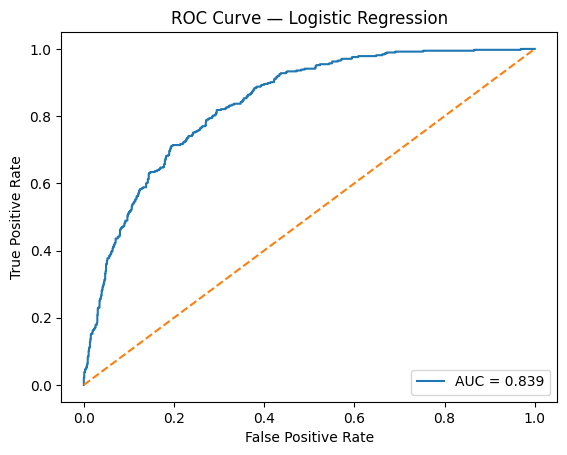

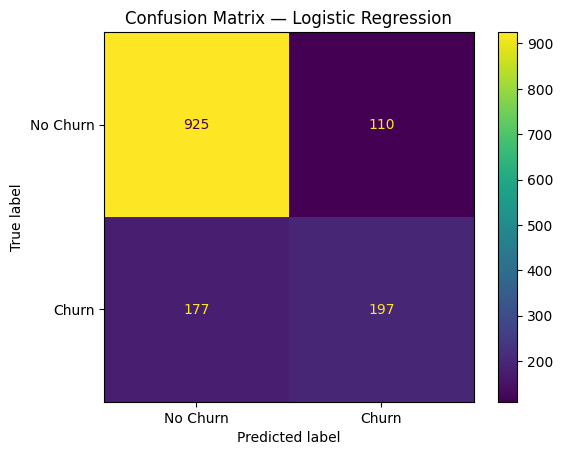

,Model,AUC ROC,AP (PR-AUC),Accuracy,Precision,Recall,F1,Train Time (s),Test Time (s),ROC Plot,CM Plot
0,Logistic Regression,0.838888,0.630339,0.796309,0.641694,0.526738,0.578561,0.033823,0.003715,model_outputs/roc_logistic_regression.png,model_outputs/cm_logistic_regression.png


In [ ]:
# %% Re-run LR block
res_lr = run_model_block(
    "Logistic Regression",
    LogisticRegression(solver="liblinear", max_iter=2000, random_state=42),
    scale=True
)
results.append(res_lr)
pd.DataFrame([res_lr])


# **SVM**

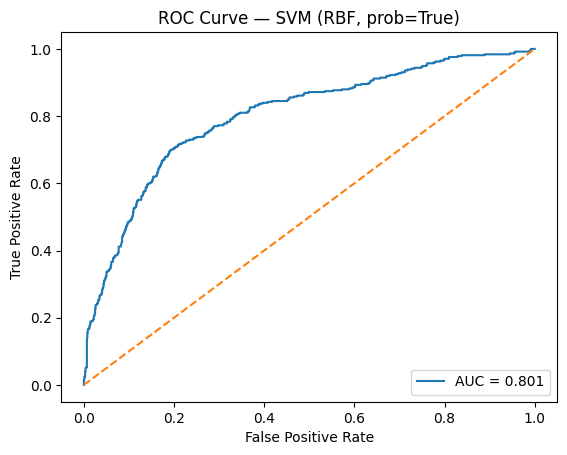

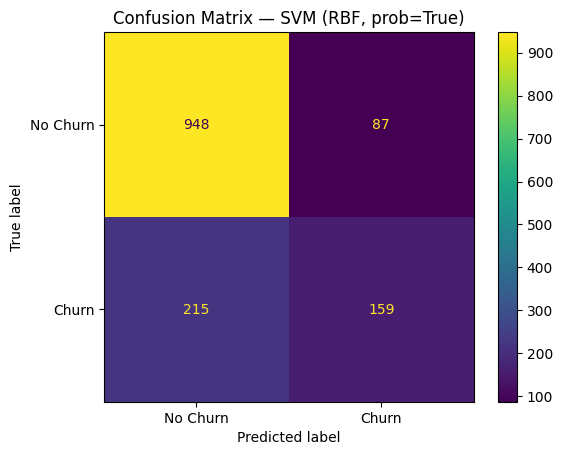

,Model,AUC ROC,AP (PR-AUC),Accuracy,Precision,Recall,F1,Train Time (s),Test Time (s),ROC Plot,CM Plot
0,"SVM (RBF, prob=True)",0.800834,0.617659,0.785664,0.646341,0.425134,0.512903,5.498521,0.288441,model_outputs/roc_svm__rbf__prob_true.png,model_outputs/cm_svm__rbf__prob_true.png


In [ ]:
# SVM (RBF, prob=True)
if 'results' not in locals():
    results = []

res_svm = run_model_block(
    "SVM (RBF, prob=True)",
    SVC(probability=True, kernel="rbf", random_state=42),
    scale=True
)
results.append(res_svm)
pd.DataFrame([res_svm])


# **Decision Tree**

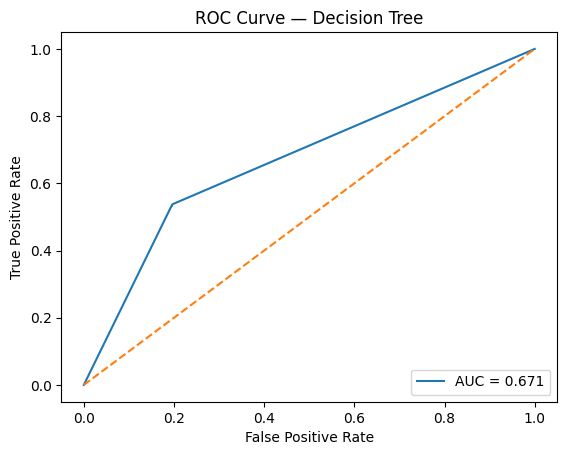

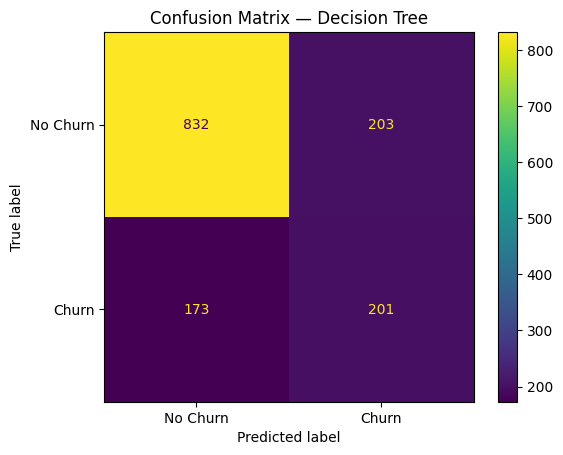

,Model,AUC ROC,AP (PR-AUC),Accuracy,Precision,Recall,F1,Train Time (s),Test Time (s),ROC Plot,CM Plot
0,Decision Tree,0.670641,0.390155,0.733144,0.497525,0.537433,0.51671,0.049946,0.002417,model_outputs/roc_decision_tree.png,model_outputs/cm_decision_tree.png


In [ ]:
# Decision Tree
res_dt = run_model_block(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42),
    scale=False
)
results.append(res_dt)
pd.DataFrame([res_dt])


#  **Random Forest**

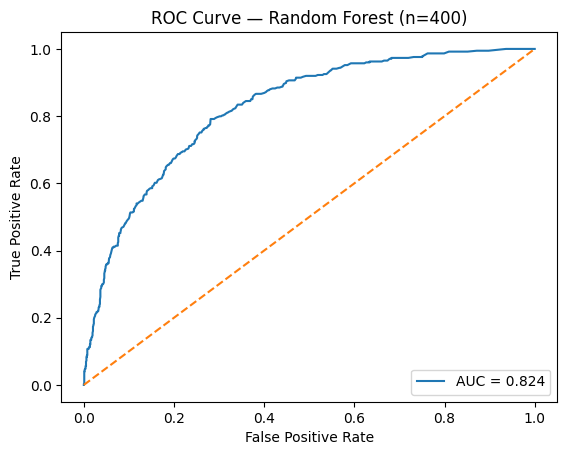

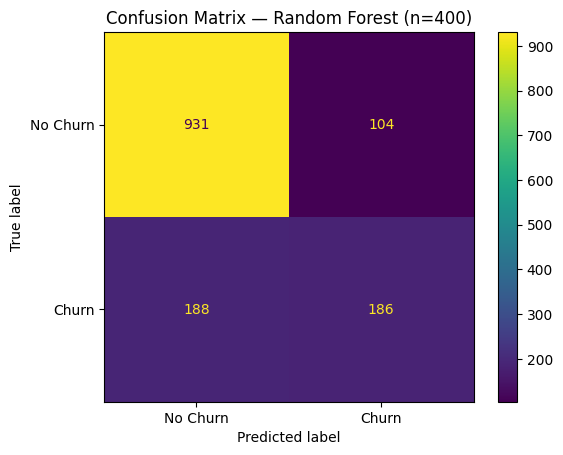

,Model,AUC ROC,AP (PR-AUC),Accuracy,Precision,Recall,F1,Train Time (s),Test Time (s),ROC Plot,CM Plot
0,Random Forest (n=400),0.824253,0.620963,0.792761,0.641379,0.497326,0.560241,4.265374,0.163235,model_outputs/roc_random_forest__n_400.png,model_outputs/cm_random_forest__n_400.png


In [ ]:
# Random Forest
res_rf = run_model_block(
    "Random Forest (n=400)",
    RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    scale=False
)
results.append(res_rf)
pd.DataFrame([res_rf])


# **Gradient Boosting**

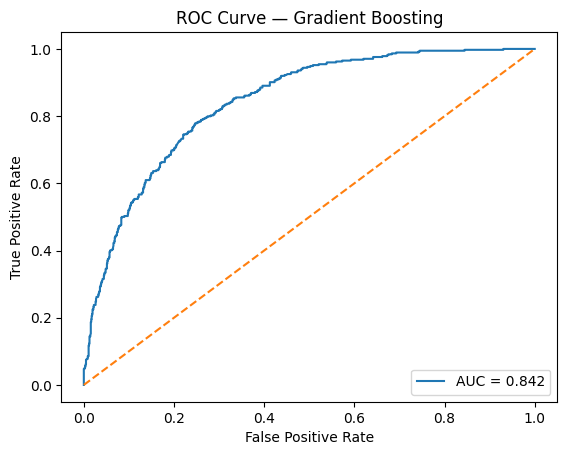

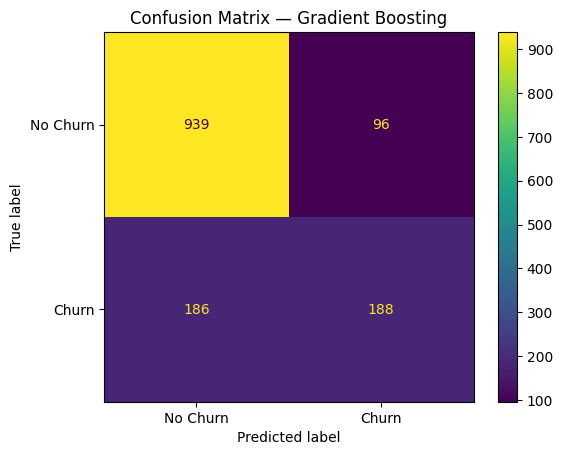

,Model,AUC ROC,AP (PR-AUC),Accuracy,Precision,Recall,F1,Train Time (s),Test Time (s),ROC Plot,CM Plot
0,Gradient Boosting,0.84194,0.65074,0.799858,0.661972,0.502674,0.571429,1.390867,0.005907,model_outputs/roc_gradient_boosting.png,model_outputs/cm_gradient_boosting.png


In [ ]:

res_gb = run_model_block(
    "Gradient Boosting",
    GradientBoostingClassifier(random_state=42),
    scale=False
)
results.append(res_gb)
pd.DataFrame([res_gb])


# **Combined result of all models**

In [ ]:
# %% Leaderboard (aggregate & save)
if 'results' not in globals():
    results = []
leaderboard = pd.DataFrame(results).sort_values(
    ["AUC ROC", "AP (PR-AUC)", "F1"], ascending=False
).reset_index(drop=True)

os.makedirs(OUTPUT_DIR, exist_ok=True)
csv_path = os.path.join(OUTPUT_DIR, "churn_model_comparison_metrics.csv")
leaderboard.to_csv(csv_path, index=False)

print("Saved leaderboard to:", csv_path)
leaderboard


Saved leaderboard to: model_outputs/churn_model_comparison_metrics.csv


,Model,AUC ROC,AP (PR-AUC),Accuracy,Precision,Recall,F1,Train Time (s),Test Time (s),ROC Plot,CM Plot
0,Gradient Boosting,0.841940,0.650740,0.799858,0.661972,0.502674,0.571429,1.390867,0.005907,model_outputs/roc_gradient_boosting.png,model_outputs/cm_gradient_boosting.png
1,Logistic Regression,0.838888,0.630339,0.796309,0.641694,0.526738,0.578561,0.033823,0.003715,model_outputs/roc_logistic_regression.png,model_outputs/cm_logistic_regression.png
2,Random Forest (n=400),0.824253,0.620963,0.792761,0.641379,0.497326,0.560241,4.265374,0.163235,model_outputs/roc_random_forest__n_400.png,model_outputs/cm_random_forest__n_400.png
3,"SVM (RBF, prob=True)",0.800834,0.617659,0.785664,0.646341,0.425134,0.512903,5.498521,0.288441,model_outputs/roc_svm__rbf__prob_true.png,model_outputs/cm_svm__rbf__prob_true.png
4,Decision Tree,0.670641,0.390155,0.733144,0.497525,0.537433,0.516710,0.049946,0.002417,model_outputs/roc_decision_tree.png,model_outputs/cm_decision_tree.png


# **Cross Validation using K-Fold**

In [ ]:
# %% Cross-validation (single block for all models)
from sklearn.model_selection import StratifiedKFold, cross_validate

models_cv = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                     ("model", LogisticRegression(solver="liblinear", max_iter=2000, random_state=42))]),
    "SVM (RBF, prob=True)": Pipeline([("scaler", StandardScaler()),
                                      ("model", SVC(probability=True, kernel="rbf", random_state=42))]),
    "Decision Tree": Pipeline([("model", DecisionTreeClassifier(random_state=42))]),
    "Random Forest (n=400)": Pipeline([("model", RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([("model", GradientBoostingClassifier(random_state=42))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

rows = []
for name, pipe in models_cv.items():
    cv_res = cross_validate(pipe, X_full, y_full, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    rows.append({
        "Model": name,
        "ROC AUC (mean)": np.mean(cv_res["test_roc_auc"]),
        "ROC AUC (std)":  np.std(cv_res["test_roc_auc"]),
        "Accuracy (mean)": np.mean(cv_res["test_accuracy"]),
        "F1 (mean)": np.mean(cv_res["test_f1"]),
        "Precision (mean)": np.mean(cv_res["test_precision"]),
        "Recall (mean)": np.mean(cv_res["test_recall"]),
    })

cv_table = pd.DataFrame(rows).sort_values(["ROC AUC (mean)", "F1 (mean)"], ascending=False).reset_index(drop=True)

cv_csv = os.path.join(OUTPUT_DIR, "cv_results.csv")
cv_table.to_csv(cv_csv, index=False)
print("Saved cross-validation results to:", cv_csv)
cv_table


Saved cross-validation results to: model_outputs/cv_results.csv


,Model,ROC AUC (mean),ROC AUC (std),Accuracy (mean),F1 (mean),Precision (mean),Recall (mean)
0,Gradient Boosting,0.847092,0.011542,0.802780,0.581726,0.664630,0.517373
1,Logistic Regression,0.842565,0.014896,0.804057,0.592698,0.660074,0.538226
2,Random Forest (n=400),0.826000,0.012623,0.789007,0.550504,0.631680,0.488469
3,"SVM (RBF, prob=True)",0.797288,0.027534,0.796531,0.548438,0.666964,0.465996
4,Decision Tree,0.654129,0.011336,0.724407,0.491261,0.481656,0.501859
